In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#mountdrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##4a)The dataset contains data points collected from a Combined Cycle Power Plant over 6 years (2006-2011), when the power plant was set to work with full load. Features consist of hourly average ambient variables Temperature (T), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (EP) of the plant.
(a) Download the Combined Cycle Power Plant data1
from:
https://archive.ics.uci.edu/ml/datasets/Combined+Cycle+Power+Plant

#ReadMe.txt
The dataset contains 9568 data points collected from a Combined Cycle Power Plant over 6 years (2006-2011), when the power plant was set to work with full load. Features consist of hourly average ambient variables Temperature (T), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (EP)  of the plant.
A combined cycle power plant (CCPP) is composed of gas turbines (GT), steam turbines (ST) and heat recovery steam generators. In a CCPP, the electricity is generated by gas and steam turbines, which are combined in one cycle, and is transferred from one turbine to another. While the Vacuum is colected from and has effect on the Steam Turbine, he other three of the ambient variables effect the GT performance.
For comparability with our baseline studies, and to allow 5x2 fold statistical tests be carried out, we provide the data shuffled five times. For each shuffling 2-fold CV is carried out and the resulting 10 measurements are used for statistical testing.
We provide the data both in .ods and in .xlsx formats.

Relevant Papers to cite:

Pınar Tüfekci, Prediction of full load electrical power output of a base load operated combined cycle power plant using machine learning methods, International Journal of Electrical Power & Energy Systems, Volume 60, September 2014, Pages 126-140, ISSN 0142-0615, http://dx.doi.org/10.1016/j.ijepes.2014.02.027.
(http://www.sciencedirect.com/science/article/pii/S0142061514000908)

Heysem Kaya, Pınar Tüfekci , Sadık Fikret Gürgen: Local and Global Learning Methods for Predicting Power of a Combined Gas & Steam Turbine, Proceedings of the International Conference on Emerging Trends in Computer and Electronics Engineering ICETCEE 2012, pp. 13-18 (Mar. 2012, Dubai)


In [6]:
#looks like the dataset has been shuffled 5 times resulting. Lets use sheet1 for now
df0 = pd.read_excel('/content/drive/MyDrive/Grad_school/USC/EE559/HW2/Folds5x2_pp.xlsx', sheet_name=0)

## 4bi)How many rows are in this data set? How many columns? What do the rows and columns represent?

In [11]:
df0.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [16]:
df0.shape
#there are 9568 rows and 5 columns. The rows represent data hourly averages of the ambient variables they represent. The columns represent each individual variables
#AT = Ambient Temperature
#V = Exhaust Vacuum
#AP = Ambient Pressure
#RH = Relative Humidity
#PE = Enery Output (readme.txt says its EP, but I think its EP)

(9568, 5)

In [13]:
df0.columns

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')

#4bii) Make pairwise scatterplots (scatter matrix) of all the varianbles in the data set including the predictors (independent variables) with the dependent variable. Describe your findings.

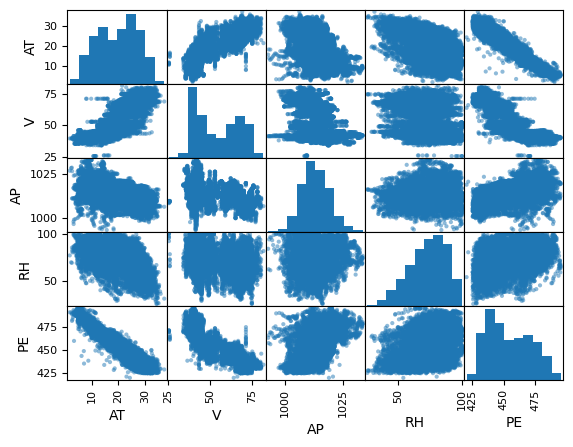

In [17]:
from pandas.plotting import scatter_matrix
scatter_matrix(df0)
plt.show()

#My findings


1.   As PE (energy output) increases, AT (Abiment Temperature) decreases in a strongly related way. I'd say this negatively coorelated. Appears to be very linear.
2.   As PE increases, V (Exhaust Vacuum) decreases, but not as strong as AT.
3.   AP (Ambient Pressure) vs RH (Relative Humidity) looks like a cloud, so I'd say its not really correlated.
4.   AT vs V shows a positive trend. Could be linear, but maybe quadratic due to shape. Linear may fit, but quadratic looks better.



## 4biii) What are the mean, the median, range, first and third quartiles, and interquartile ranges of each of the variables in the dataset? Summarize them in a table

In [20]:
#df0.describe()
#missing:
#1. range = max - min
#2. IQR = Q3-Q1
table = df0.describe()
table

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [21]:
table.loc['Range'] = table.loc['max'] - table.loc['min']
table.loc['IQR'] = table.loc['75%'] - table.loc['25%']
table

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000
Range,35.300000,56.200000,40.410000,74.600000,75.500000
IQR,12.210000,24.800000,8.160000,21.502500,28.680000


##4c) For each predictor, fit a simple linear regression model to predict the response. Describe your results. In which of the models is there a statistically significant association between the predictor and the response? Create some plots to back up your assertions. Are there any outliers that you would like to remove from your data for each of these regression tasks?

In [22]:
#use statsmodels to do linear regression
import statsmodels.api as sm

Now, we would like to predict $\hat{PE}$, which is the enery output. We want to predict the energy output for each of the predictors. So basically, the linear regression tasks is
$$\hat{PE} = \beta_0 + \beta_1 AT+\epsilon$$
$$\hat{PE} = \beta_0 + \beta_1 V+\epsilon$$
$$\hat{PE} = \beta_0 + \beta_1 AP+\epsilon$$
$$\hat{PE} = \beta_0 + \beta_1 RH+\epsilon$$

In [34]:
#PE as a function of AT
AT_x = df0['AT']
AT_x = sm.add_constant(AT_x)
AT_y = df0['PE']
AT_model = sm.OLS(AT_y, AT_x)
AT_fit = AT_model.fit()
print(AT_fit.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:41:01   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   3177.280      0.0

# Analysis of $$\hat{PE} = \beta_0+\beta_1AT+\epsilon$$
Based off the regression, the model is $\hat{PE}=  497.0341 - 2.1713AH$ with an $R^2=.899$. This shows that AH alone explains the variation on PE, showing us that AT strongly associated with PE

Lets focus on the $\hat{\beta_1}$ data. First, we see that $t = -291$ and $p=0.00$. Let us observe this data. So these $t$ and $p$ values are used to help address the hypothesis testing we are doing on $\hat{\beta_1}$. The main question we are asking is the following:

$$H_0 : \hat{\beta_1} = 0 \quad \text{Null Hypothesis}$$
$$H_1 : \hat{\beta_1} \neq 0\quad \text{Alternative Hypothesis}$$

$t$ and $p$ are testing if $H_0$ is true or not. Based off of our standared error (std err) for $\hat{\beta_1}$, we have $SE(\hat{\beta_1})=0.007$. This is used to calculate our t-statistic
$$|t |= \left|\frac{\hat{\beta_1} - 0}{SE(\hat{\beta_1})}\right| = \left|\frac{-2.17-0}{0.007}\right| = 291$$
This means that -2.17 observation is is 291 standard errors away from zero. If null hypothesis were true, and indeed $\hat{\beta_1} = 0$, then expect $\hat{\beta_1} = 0.000\pm 0.007$ to be where we would fall, but we observed $\hat{\beta_1}=-2.17$ which is 291 "0.0007's" away from zero. This large t-statistic means it is highly unlikely that our measuremnt of -2.17 is a result of random noise. This t-statistic is related to the p-value.

$$p = P(|T| \ge |t|  | H_0=true)$$
our p-value is the probability that we observe data as extreme or more than our $\hat{\beta_1} = -2.17$ value given our spread in data $SE(\hat{\beta_1})$. This is encompassed in the t-statistic. For t-statistic, $t_{n-p-1}$ is our t-disticpution with $n-p-1$ degrees of freedom. here, $n=9568$ which is the data points in our excel sheet. $p=features$ which is 1 since we only are using AT to predict. So we have $t_{9566}$ which for large dof is a normal distribution $\mathcal N(0,\sigma^2)$.So our t-statistic is our area under the tails of oru gaussian. So a large $t=291$ means we are taking the area under the curve of the tails on both sides of our normal distribution. That area is our p-value and represents the probability that we observe data as extreme or more than our observed value.

This large t value leads to a small p value which is 0.000 for us, which indicates that there is a 0.000 (0 due to python display) probability that we observe $\hat{\beta_1}=-2.17$ to be generated from noise. There is a 0.000 probability that if the null hypothesis were true ($H_0:\hat{\beta_1}=0$), we would observe -2.17. Therefore we reject the null hypothesis in favor of the alternative.

In [41]:
#lets store the results as we do the calcualtions to get a table
lin_reg_table = []

In [42]:
lin_reg_table.append({
    'Predictor': 'AT',
    'beta_0': AT_fit.params['const'],
    'beta_1': AT_fit.params['AT'],
    'SE': AT_fit.bse['AT'],
    't': AT_fit.tvalues['AT'],
    'p': AT_fit.pvalues['AT'],
    'R^2': AT_fit.rsquared
    })

In [45]:
pd.DataFrame(lin_reg_table).round(4)
#good. Lets move on

,Predictor,beta_0,beta_1,SE,t,p,R^2
0,AT,497.0341,-2.1713,0.0074,-291.7152,0.0,0.8989


In [46]:
#PE as a function of V
V = df0['V']
V = sm.add_constant(V)
y = df0['PE']
V_model = sm.OLS(y, V)
V_fit = V_model.fit()
print(V_fit.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:44:58   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        517.8015      0.378   1370.218      0.0

In [47]:
lin_reg_table.append({
    'Predictor': 'V',
    'beta_0': V_fit.params['const'],
    'beta_1': V_fit.params['V'],
    'SE': V_fit.bse['V'],
    't': V_fit.tvalues['V'],
    'p': V_fit.pvalues['V'],
    'R^2': V_fit.rsquared
    })

In [50]:
#PE as a function of  AP
AP = df0['AP']
AP = sm.add_constant(AP)
y = df0['PE']
AP_model = sm.OLS(y, AP)
AP_fit = AP_model.fit()
print(AP_fit.summary())

lin_reg_table.append({
    'Predictor': 'AP',
    'beta_0': AP_fit.params['const'],
    'beta_1': AP_fit.params['AP'],
    'SE': AP_fit.bse['AP'],
    't': AP_fit.tvalues['AP'],
    'p': AP_fit.pvalues['AP'],
    'R^2': AP_fit.rsquared
    }

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:47:41   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1055.2610     25.459    -41.449      0.0

In [52]:
#finally, PE as a function of RH
RH = df0['RH']
RH = sm.add_constant(RH)
y = df0['PE']
RH_model = sm.OLS(y, RH)
RH_fit = RH_model.fit()
print(RH_fit.summary())

lin_reg_table.append({
    'Predictor': 'RH',
    'beta_0': RH_fit.params['const'],
    'beta_1': RH_fit.params['RH'],
    'SE': RH_fit.bse['RH'],
    't': RH_fit.tvalues['RH'],
    'p': RH_fit.pvalues['RH'],
    'R^2': RH_fit.rsquared
    })

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:49:22   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        420.9618      0.823    511.676      0.0

In [53]:
pd.DataFrame(lin_reg_table).round(4)

,Predictor,beta_0,beta_1,SE,t,p,R^2
0,AT,497.0341,-2.1713,0.0074,-291.7152,0.0,0.8989
1,V,517.8015,-1.1681,0.0068,-172.4015,0.0,0.7565
2,AP,-1055.2610,1.4899,0.0251,59.2962,0.0,0.2688
3,RH,420.9618,0.4557,0.0110,41.3987,0.0,0.1519


In [54]:
lin_reg_results = pd.DataFrame(lin_reg_table).round(4)
lin_reg_results

,Predictor,beta_0,beta_1,SE,t,p,R^2
0,AT,497.0341,-2.1713,0.0074,-291.7152,0.0,0.8989
1,V,517.8015,-1.1681,0.0068,-172.4015,0.0,0.7565
2,AP,-1055.2610,1.4899,0.0251,59.2962,0.0,0.2688
3,RH,420.9618,0.4557,0.0110,41.3987,0.0,0.1519


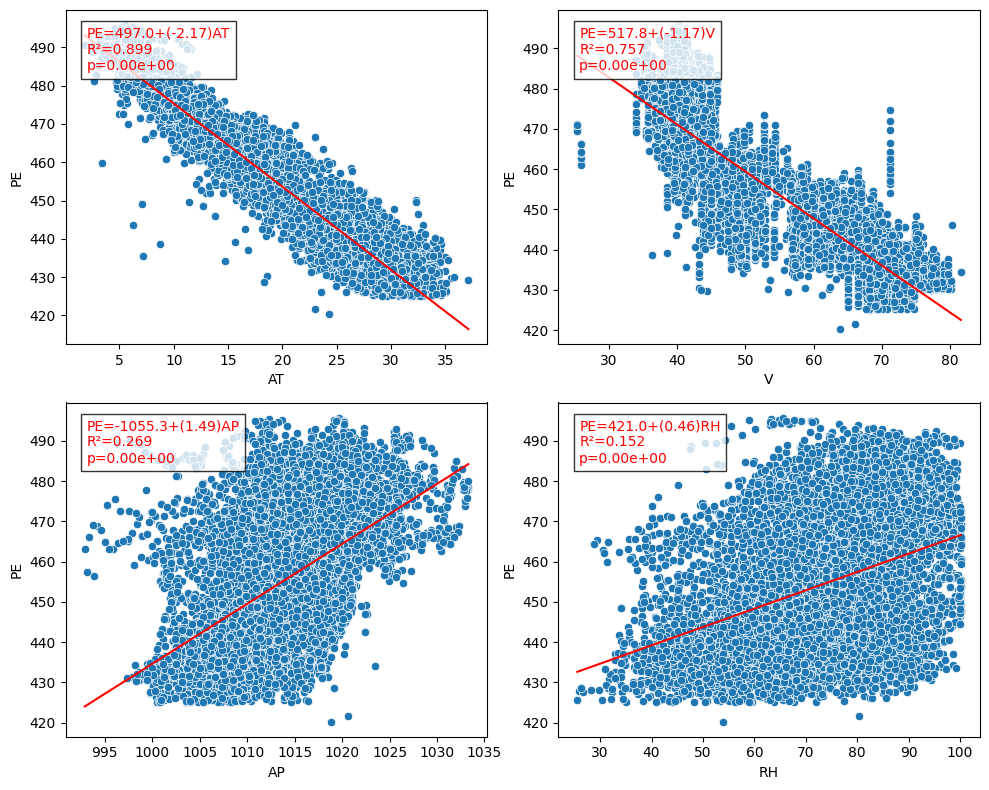

In [65]:
#to compare, let us print the plots from the scatter matrix.

fig, ax = plt.subplots(2,2, figsize=(10,8))

models = {
    'AT': AT_fit,
    'V': V_fit,
    'AP': AP_fit,
    'RH': RH_fit
}

axes = ax.flatten()

for i, pred in enumerate(models):

    fit = models[pred]

    sns.scatterplot(
        x=df0[pred],
        y=df0['PE'],
        ax=axes[i]
    )

    x = np.linspace(
        df0[pred].min(),
        df0[pred].max(),

    )

    y = fit.params['const'] + fit.params[pred] * x

    axes[i].plot(
        x, y,
        color='red'
    )

    axes[i].text(
        0.05, 0.95,
        f'PE={fit.params["const"]:.1f}+({fit.params[pred]:.2f}){pred}\n'
        f'R²={fit.rsquared:.3f}\n'
        f'p={fit.pvalues[pred]:.2e}',
        transform=axes[i].transAxes,
        verticalalignment='top',
        color='red',
        bbox=dict(facecolor='white', alpha=0.8)
    )

plt.tight_layout()
plt.show()

##Analysis


*   PE vs AT shows the strongest linear coorelation with the R^2 = 0.899, meaning there is strong evidence of coorelation. The small p value inidicates there is strong enough evidence to  reject the hypothesis that AT is not statistically significant. There is strong linear relationship between PE and AH.
*   PE vs V shows still a strong linear relatipship, but not as strong as PE vs AT. These may be doe to some of the outliers at V = 70 and V below 30. The spread in PE is larger as V increses, leading to a larger standard error
*   PE vs AP shows a positive linear relationship. The R^2 = 0.269 shows that though the data is linear, there is still a lot of variability in the data. The standard error here is the largesst, but still evidence to show there is statistical significance between PE and AP.
*   PE vs RH still has a positive linear relationship that is statistically significant, but the R^2=0.152 shows that the ability for this linear model to predict is not as strong as the others (weakest).


PE vs V is the only dataset with outliers I wish to remove. Though there are some outliers in PE vs AT, those outliers still gave significant results, and would probably affect the results very little.


## 4d) Fit a multiple regression model to predict the response using all of the predictors.Describe your results. For which predictors can we reject the null hypothesis $H_0 : β_j = 0$?

This problem is now asking to predict PE using all 4 predictors
$$\hat{P_E} = \beta_0 + \beta_1AT+\beta_2V+\beta_3AP+\beta_4RH+\epsilon$$
to do multiple linear regression. This means our dof is $n-p-1 = 9568-4-1=9563$. Since this is large, adding 3 more predictors probably doesnt change our dof much since we have a lot of data (n=9568).

In [66]:
#lets build the multiple linear regression model
x = df0[['AT','V','AP','RH']]
y = df0['PE']
x = sm.add_constant(x)
model = sm.OLS(y, x)
fit = model.fit()
print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        18:20:17   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

In [67]:
lin_reg_results

,Predictor,beta_0,beta_1,SE,t,p,R^2
0,AT,497.0341,-2.1713,0.0074,-291.7152,0.0,0.8989
1,V,517.8015,-1.1681,0.0068,-172.4015,0.0,0.7565
2,AP,-1055.2610,1.4899,0.0251,59.2962,0.0,0.2688
3,RH,420.9618,0.4557,0.0110,41.3987,0.0,0.1519


## Discussion
The 1st table is the results of multiple linear regression, and the table following is the results from individual linear regression to compare. Here are some observations:



*   The R^2 value increased in multiple linear regression!! This indicates that the predictive power of all predictors at the same time is stronger than the predictive power of any of them individually.
*   p-value for each of the variables for multiple linear regression are all close to 0. This indicates each variable $\vec{\beta_j} = [AT,V,AP,RH]$ are all statistically significant. The null hypothesis $H_0: \vec{\beta_j}=0$ for all $j$ is rejected given the p-value. All 4 predictors are statistically significant.
*  AP's results changed drastically. In individual linear regression; $\hat{\beta_1} = 1.4899$, $SE=0.0251$, which is the largest standard error. In multiple linear regression, we now have $\hat{\beta_3}=0.0621$, $SE = 0.009$. The standard error decresed, and the coefficient was most likely adjusted to a better predictive value.
* RH sign changed?! For individual linear $\hat{\beta_{RH}} = 0.4557$. For multiple linear regression $\hat{\beta_{RH}} = -0.1581$. AFter taking into account the other predictive variables AT, V and AP, RH now has a negative relationship with PE.
*  Based off the original scatter matrix, we know that the variables are coorelated, so interpretation of multiple linear regression is not as simple. For example, the scatter matrix showed that there is a seemingly strong negative linear relationship between the independent variables AT, V, AP, RH. For example, AT vs V scatter matrix suggest a positive linear (possibly quadratic?) relationship between the variables. There is no longer independence, so if we wish to use these as independent variables to model PE in a multiple linear regression,  interpretation is difficult since in linear regression, we assume all variables are constant as we change the other variable to predict dependent variable. This assumption is ruined since we know the independent variables are seemingly coorelated.


## 4d) How do your results from 4c compare to your results from 4d? Create a plot displaying the univariate regression coefficients from 4c on the x-axis, and the multiple regression coefficients from 4d on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate in the multiple linear regression model is shown on the y-axis.

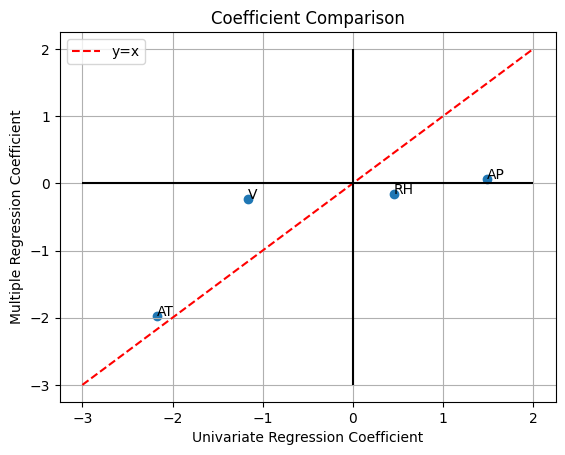

In [89]:
univariate = [-2.1713,-1.1681,1.4899,0.4557]
multiple = [-1.9775, -0.2339, 0.0621, -0.1581]
plt.scatter(univariate, multiple)
plt.annotate('AT', (-2.1713, -1.9775))
plt.annotate('V',  (-1.1681, -0.2339))
plt.annotate('AP', ( 1.4899,  0.0621))
plt.annotate('RH', ( 0.4557, -0.1581))
plt.xlabel('Univariate Regression Coefficient')
plt.ylabel('Multiple Regression Coefficient')
plt.title('Coefficient Comparison')
#lets plot the line y=x for reference
t = np.linspace(-3,2)
plt.plot(t,t, 'r--', label = 'y=x')
plt.vlines(0,-3,2, 'k', linestyles='solid')
plt.hlines(0,-3,2, 'k', linestyles='solid')
plt.legend()
plt.grid()
plt.show()


I guess one interpretation is that the closer the point is to the line y=x, the less it changed.  RH being in quadrant IV shows the sign change. AP in quad I shows that it went form positive to posititve. AT and V being in quad III shows it went from negative to negative. AP changed the most in magnitude.

## 4f) Is there evidence of nonlinear association between any of the predictors and the response? To answer this question, for each predictor X, fit a model of the form $Y = \beta_0+\beta_1X+\beta_2X^2+\beta_3X^3+\epsilon$

=> here we go. I was thinking of fitting a quadratic, but lets fit a cubic. If truly quadratic, then the cubic term is small. This will be exciting. Now, instead of
$$\hat{PE} = \beta_0 + \beta_1 AT+\epsilon$$
$$\hat{PE} = \beta_0 + \beta_1 V+\epsilon$$
$$\hat{PE} = \beta_0 + \beta_1 AP+\epsilon$$
$$\hat{PE} = \beta_0 + \beta_1 RH+\epsilon$$

Lets to

$$\hat{PE} = \beta_0+\beta_1AT+\beta_2 AT^2+\beta_3AT^3+\epsilon$$
$$\hat{PE} = \beta_0+\beta_1V+\beta_2 V^2+\beta_3V^3+\epsilon$$
$$\hat{PE} = \beta_0+\beta_1AP+\beta_2 AP^2+\beta_3AP^3+\epsilon$$
$$\hat{PE} = \beta_0+\beta_1RH+\beta_2 RH^2+\beta_3RH^3+\epsilon$$

In [95]:
type(df0['AT']) # this is a [n] object and is a series

pandas.core.series.Series

In [96]:
type(df0[['AT']]) #this is a [nx1] 2D data that is expected or the polyfit and is a dataframe.

pandas.core.frame.DataFrame

In [118]:
from sklearn.preprocessing import PolynomialFeatures
#initiate type of polynomial. include_bias=True gives the beta_0 term
poly = PolynomialFeatures(degree=3,include_bias=True)
#poly.fit_transform takes in AT data and creates 1, AT, AT^2, AT^3
x_poly = poly.fit_transform(df0[['AT']])
poly.get_feature_names_out(['AT']) #can now see that we have 1, AT, AT^2, AT^3
#fit the dependent variable PE to AT cubic
y = df0['PE']
AT_polyfit = sm.OLS(y, x_poly).fit() #fit using Ordinary Least Squares (OLS) x_poly to y data.
print(AT_polyfit.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:30:45   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        492.7281      0.673    732.248      0.0

In [119]:
#now lets generate a similar results table
uni_poly_reg = []
uni_poly_reg.append({
    'Predictor': 'AT',

    'beta0': AT_polyfit.params.iloc[0],
    'beta1': AT_polyfit.params.iloc[1],
    'beta2': AT_polyfit.params.iloc[2],
    'beta3': AT_polyfit.params.iloc[3],

    'SE1': AT_polyfit.bse.iloc[1],
    'SE2': AT_polyfit.bse.iloc[2],
    'SE3': AT_polyfit.bse.iloc[3],

    't1': AT_polyfit.tvalues.iloc[1],
    't2': AT_polyfit.tvalues.iloc[2],
    't3': AT_polyfit.tvalues.iloc[3],

    'p1': AT_polyfit.pvalues.iloc[1],
    'p2': AT_polyfit.pvalues.iloc[2],
    'p3': AT_polyfit.pvalues.iloc[3],

    'R2': AT_polyfit.rsquared
})

In [120]:
pd.DataFrame(uni_poly_reg).round(4)

,Predictor,beta0,beta1,beta2,beta3,SE1,SE2,SE3,t1,t2,t3,p1,p2,p3,R2
0,AT,492.7281,-0.6103,-0.1251,0.0027,0.1235,0.0069,0.0001,-4.9411,-18.1989,22.5942,0.0,0.0,0.0,0.9119


In [123]:
#ok we got the flow, lets copy paste for the rest of the variables and generate summary table
poly = PolynomialFeatures(degree=3,include_bias=True)
V_poly = poly.fit_transform(df0[['V']])
y = df0['PE']
V_polyfit = sm.OLS(y, V_poly).fit()
print(V_polyfit.summary())
uni_poly_reg.append({
    'Predictor': 'V',

    'beta0': V_polyfit.params.iloc[0],
    'beta1': V_polyfit.params.iloc[1],
    'beta2': V_polyfit.params.iloc[2],
    'beta3': V_polyfit.params.iloc[3],

    'SE1': V_polyfit.bse.iloc[1],
    'SE2': V_polyfit.bse.iloc[2],
    'SE3': V_polyfit.bse.iloc[3],

    't1': V_polyfit.tvalues.iloc[1],
    't2': V_polyfit.tvalues.iloc[2],
    't3': V_polyfit.tvalues.iloc[3],

    'p1': V_polyfit.pvalues.iloc[1],
    'p2': V_polyfit.pvalues.iloc[2],
    'p3': V_polyfit.pvalues.iloc[3],

    'R2': V_polyfit.rsquared
})

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.098e+04
Date:                Sat, 06 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:31:00   Log-Likelihood:                -33585.
No. Observations:                9568   AIC:                         6.718e+04
Df Residuals:                    9564   BIC:                         6.721e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        554.1468      9.151     60.557      0.0

In [124]:
pd.DataFrame(uni_poly_reg).round(4)
#

,Predictor,beta0,beta1,beta2,beta3,SE1,SE2,SE3,t1,t2,t3,p1,p2,p3,R2
0,AT,492.7281,-0.6103,-0.1251,0.0027,0.1235,0.0069,0.0001,-4.9411,-18.1989,22.5942,0.0,0.0000,0.0000,0.9119
1,V,554.1468,-2.1444,-0.0027,0.0001,0.5088,0.0092,0.0001,-4.2145,-0.2943,2.4646,0.0,0.7685,0.0137,0.7750


In [125]:

poly = PolynomialFeatures(degree=3,include_bias=True)

AP_poly = poly.fit_transform(df0[['AP']])
RH_poly = poly.fit_transform(df0[['RH']])

y = df0['PE']

AP_polyfit = sm.OLS(y, AP_poly).fit()
RH_polyfit = sm.OLS(y, RH_poly).fit()

uni_poly_reg.append({
    'Predictor': 'AP',

    'beta0': AP_polyfit.params.iloc[0],
    'beta1': AP_polyfit.params.iloc[1],
    'beta2': AP_polyfit.params.iloc[2],
    'beta3': AP_polyfit.params.iloc[3],

    'SE1': AP_polyfit.bse.iloc[1],
    'SE2': AP_polyfit.bse.iloc[2],
    'SE3': AP_polyfit.bse.iloc[3],

    't1': AP_polyfit.tvalues.iloc[1],
    't2': AP_polyfit.tvalues.iloc[2],
    't3': AP_polyfit.tvalues.iloc[3],

    'p1': AP_polyfit.pvalues.iloc[1],
    'p2': AP_polyfit.pvalues.iloc[2],
    'p3': AP_polyfit.pvalues.iloc[3],

    'R2': AP_polyfit.rsquared
})

uni_poly_reg.append({
    'Predictor': 'RH',

    'beta0': RH_polyfit.params.iloc[0],
    'beta1': RH_polyfit.params.iloc[1],
    'beta2': RH_polyfit.params.iloc[2],
    'beta3': RH_polyfit.params.iloc[3],

    'SE1': RH_polyfit.bse.iloc[1],
    'SE2': RH_polyfit.bse.iloc[2],
    'SE3': RH_polyfit.bse.iloc[3],

    't1': RH_polyfit.tvalues.iloc[1],
    't2': RH_polyfit.tvalues.iloc[2],
    't3': RH_polyfit.tvalues.iloc[3],

    'p1': RH_polyfit.pvalues.iloc[1],
    'p2': RH_polyfit.pvalues.iloc[2],
    'p3': RH_polyfit.pvalues.iloc[3],

    'R2': RH_polyfit.rsquared
})

In [127]:
uni_poly_reg_table = pd.DataFrame(uni_poly_reg).round(4)

In [128]:
uni_poly_reg_table

,Predictor,beta0,beta1,beta2,beta3,SE1,SE2,SE3,t1,t2,t3,p1,p2,p3,R2
0,AT,492.7281,-0.6103,-0.1251,0.0027,0.1235,0.0069,0.0001,-4.9411,-18.1989,22.5942,0.0000,0.0000,0.0000,0.9119
1,V,554.1468,-2.1444,-0.0027,0.0001,0.5088,0.0092,0.0001,-4.2145,-0.2943,2.4646,0.0000,0.7685,0.0137,0.7750
2,AP,0.0747,25.2556,-0.0500,0.0000,3.0014,0.0059,0.0000,8.4147,-8.4390,8.6127,0.0000,0.0000,0.0000,0.2749
3,RH,468.4135,-1.7292,0.0321,-0.0002,0.4862,0.0073,0.0000,-3.5568,4.4330,-4.3399,0.0004,0.0000,0.0000,0.1537


In [129]:
#univariate linear regression results
lin_reg_results

,Predictor,beta_0,beta_1,SE,t,p,R^2
0,AT,497.0341,-2.1713,0.0074,-291.7152,0.0,0.8989
1,V,517.8015,-1.1681,0.0068,-172.4015,0.0,0.7565
2,AP,-1055.2610,1.4899,0.0251,59.2962,0.0,0.2688
3,RH,420.9618,0.4557,0.0110,41.3987,0.0,0.1519


#Quick things I can note


*   for V, can see that the pvalue for $\beta_2,\beta_3$ is large, meaning $V^2 , V^3$ is not statistically significant, so a linear model is okay. There is stronger evidance that there is a $V^3$ term since the pvalue is smaller than the $V^2$ pvalue.
*  Compared to the univariate linear regression results, R^2 for AT increased by 1.5 percentage points or so. This means there is nonlinear relationship in affect since the predictive power increased when introducing nonlinear terms. V also increased in R^2 with cubic term, but not as much as AT. $V^3$ seemed to be the correct polynomial term to enhance R^2.

# to answer part (f) question
There seems to be evidence that there is nonlinear interaction terms of predictors as shown by the $R^2$ value enhancement when introducting nonlinear terms specifically to AT variable. Adding $AT^2$ and $AT^3$ enhanced $R^2$ value, so those terms ehnanced predictive power of PE using AT. There is also some nonlinearity in V and RH. The pvalue for V^2 is large meaning it is statistically insignificant. V^3 is also somewhat large, but is below 0.05, whic suggest some evidence that a V^3 is statstically significant, but does little to increase R^2 compared to univariate linear regression. RH shows a similar interpretation; where $RH^2$ and $RH^3$ are statstically significant as shown by small p value, but increases R^2 by very little. AP also shows nonlinear terms are significant, but doesnt contribue to R^2 increase.

